In [44]:
import pandas as pd


In [45]:
clean_data = pd.read_csv(r'C:\Users\Hp\Desktop\My Work\Prepare before war\Data\Processed_data\war_impact_clean.csv')
clean_data.head()

,conflict_id,location,incompatibility,year,intensity_level,cumulative_intensity,type_of_conflict,gwno_a,gwno_loc,region,sugar_price,crude_oil_price,wheat_price,gold_price,country,inflation rate
0,11342,India,1,2012,1,0,3,750,750,3,0.215474,94.029167,7.504588,1679.833333,India,7.934387
1,11342,India,1,2014,1,0,3,750,750,3,0.163502,91.560000,5.776297,1256.250000,India,3.331757
2,11343,"Egypt, Israel",1,1967,2,1,2,651,"651, 666",2,0.021774,3.026667,1.599782,35.310000,"Egypt, Arab Rep.",2.832013
3,11343,"Egypt, Israel",1,1969,1,1,2,651,"651, 666",2,0.034709,3.295000,1.328638,40.839167,"Egypt, Arab Rep.",0.806310
4,11343,"Egypt, Israel",1,1970,1,1,2,651,"651, 666",2,0.037824,3.350833,1.534094,35.985833,"Egypt, Arab Rep.",12.516174


In [46]:

print('Column infomation is : ',clean_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2568 entries, 0 to 2567
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2568 non-null   int64  
 1   location              2568 non-null   object 
 2   incompatibility       2568 non-null   int64  
 3   year                  2568 non-null   int64  
 4   intensity_level       2568 non-null   int64  
 5   cumulative_intensity  2568 non-null   int64  
 6   type_of_conflict      2568 non-null   int64  
 7   gwno_a                2568 non-null   object 
 8   gwno_loc              2568 non-null   object 
 9   region                2568 non-null   object 
 10  sugar_price           2568 non-null   float64
 11  crude_oil_price       2568 non-null   float64
 12  wheat_price           2568 non-null   float64
 13  gold_price            2568 non-null   float64
 14  country               2568 non-null   object 
 15  inflation rate       

In [47]:
print("Quartile info of Data is : ", clean_data.describe())

Quartile info of Data is :          conflict_id  incompatibility         year  intensity_level  \
count   2568.000000      2568.000000  2568.000000      2568.000000   
mean    1284.931075         1.452492  1989.985981         1.253894   
std     3433.695050         0.511726    20.216991         0.435322   
min      200.000000         1.000000  1946.000000         1.000000   
25%      251.000000         1.000000  1976.000000         1.000000   
50%      308.000000         1.000000  1991.000000         1.000000   
75%      364.000000         2.000000  2007.000000         2.000000   
max    15283.000000         3.000000  2021.000000         2.000000   

       cumulative_intensity  type_of_conflict  sugar_price  crude_oil_price  \
count           2568.000000       2568.000000  2568.000000      2568.000000   
mean               0.714174          3.018692     0.117105        31.231321   
std                0.451895          0.631933     0.058258        27.153267   
min                0.0000

In [48]:
import matplotlib .pyplot as plt 
import seaborn as sns


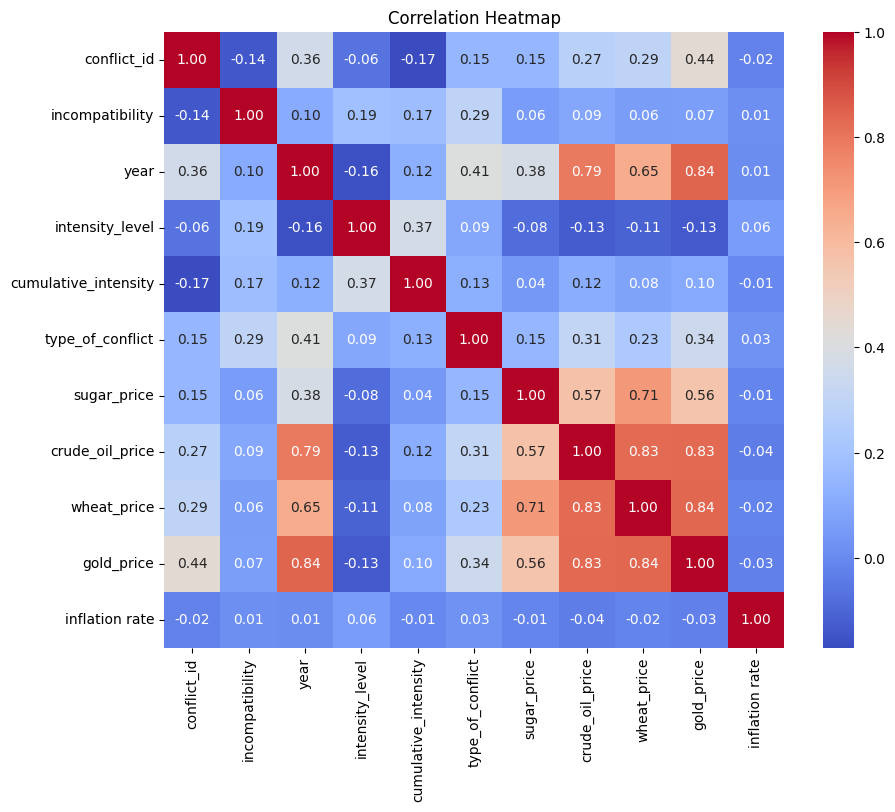

In [49]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = clean_data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

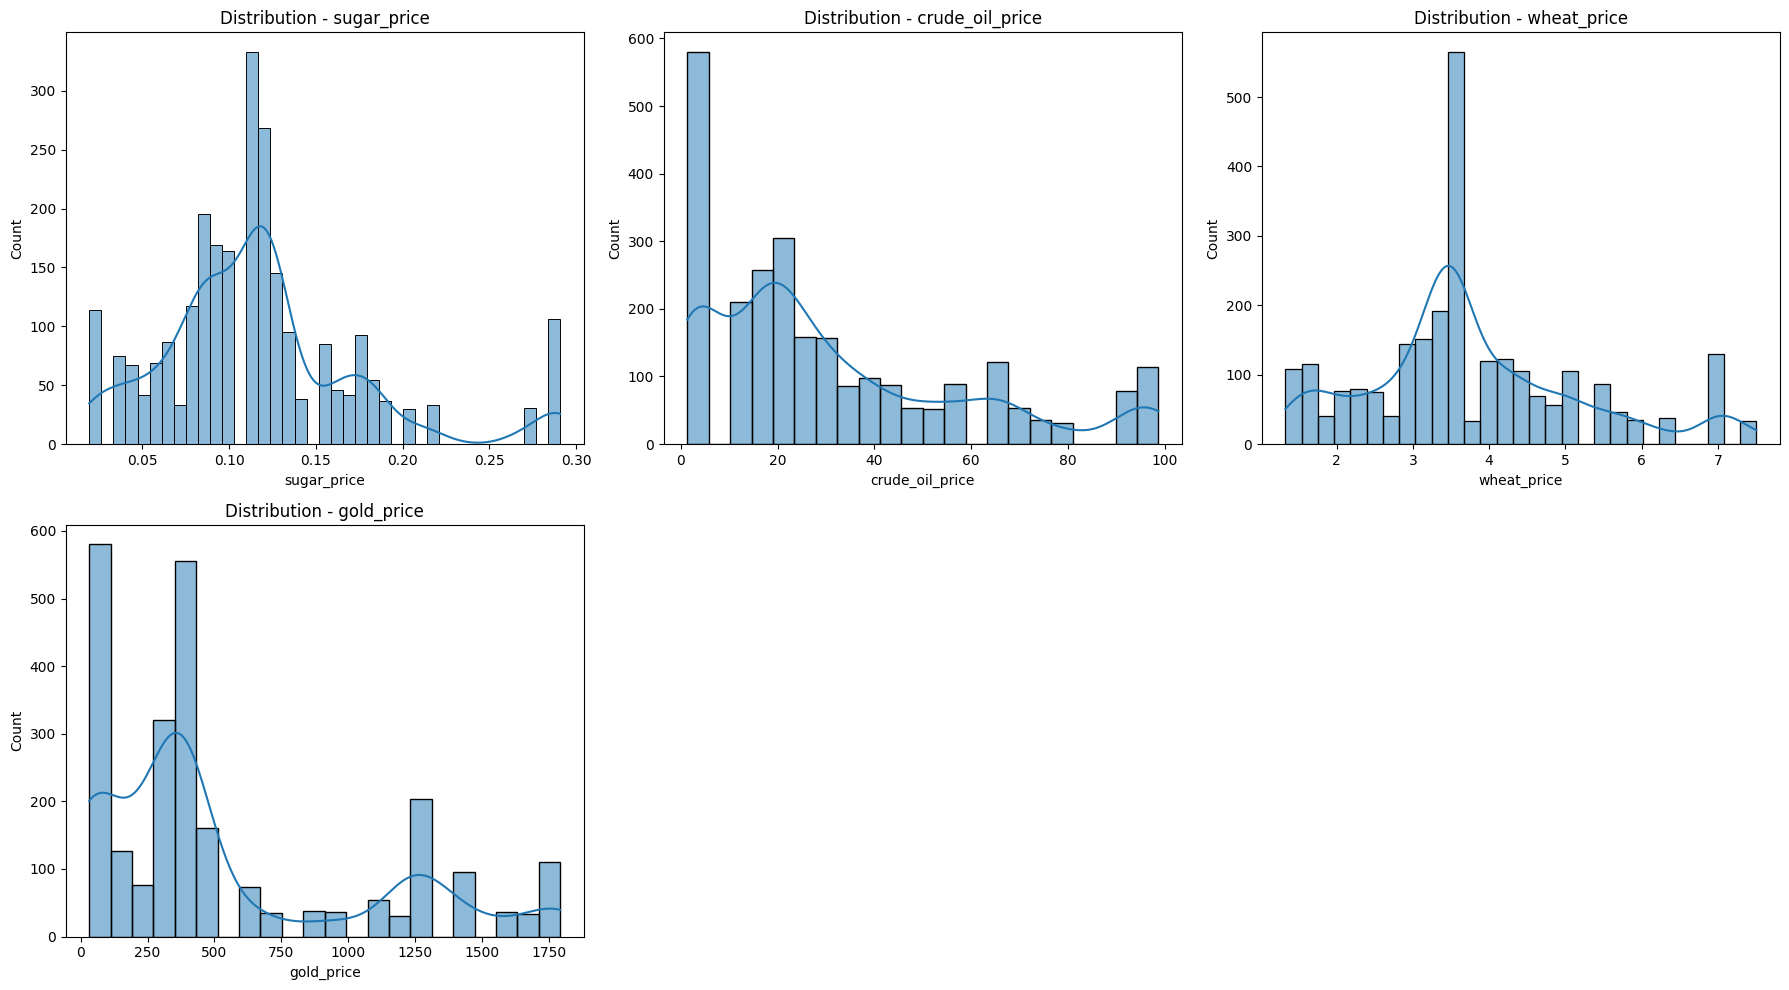

In [50]:
def plot_distribution(df, columns, figsize=(18, 10)):
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)  # subplots - s with
    axes = axes.flatten()
    
    for i, col in enumerate(columns):  
        if df[col].dtype in ['float64', 'int64']:  
            sns.histplot(df[col], ax=axes[i], kde=True)
            axes[i].set_title(f"Distribution - {col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Count")
        else:
            axes[i].set_title(f"{col} - Not numeric")
            axes[i].set_visible(False)
    
    # Extra axes hide karo
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


plot_distribution(clean_data, [
    'sugar_price',
    'crude_oil_price',
    'wheat_price',
    'gold_price',
])

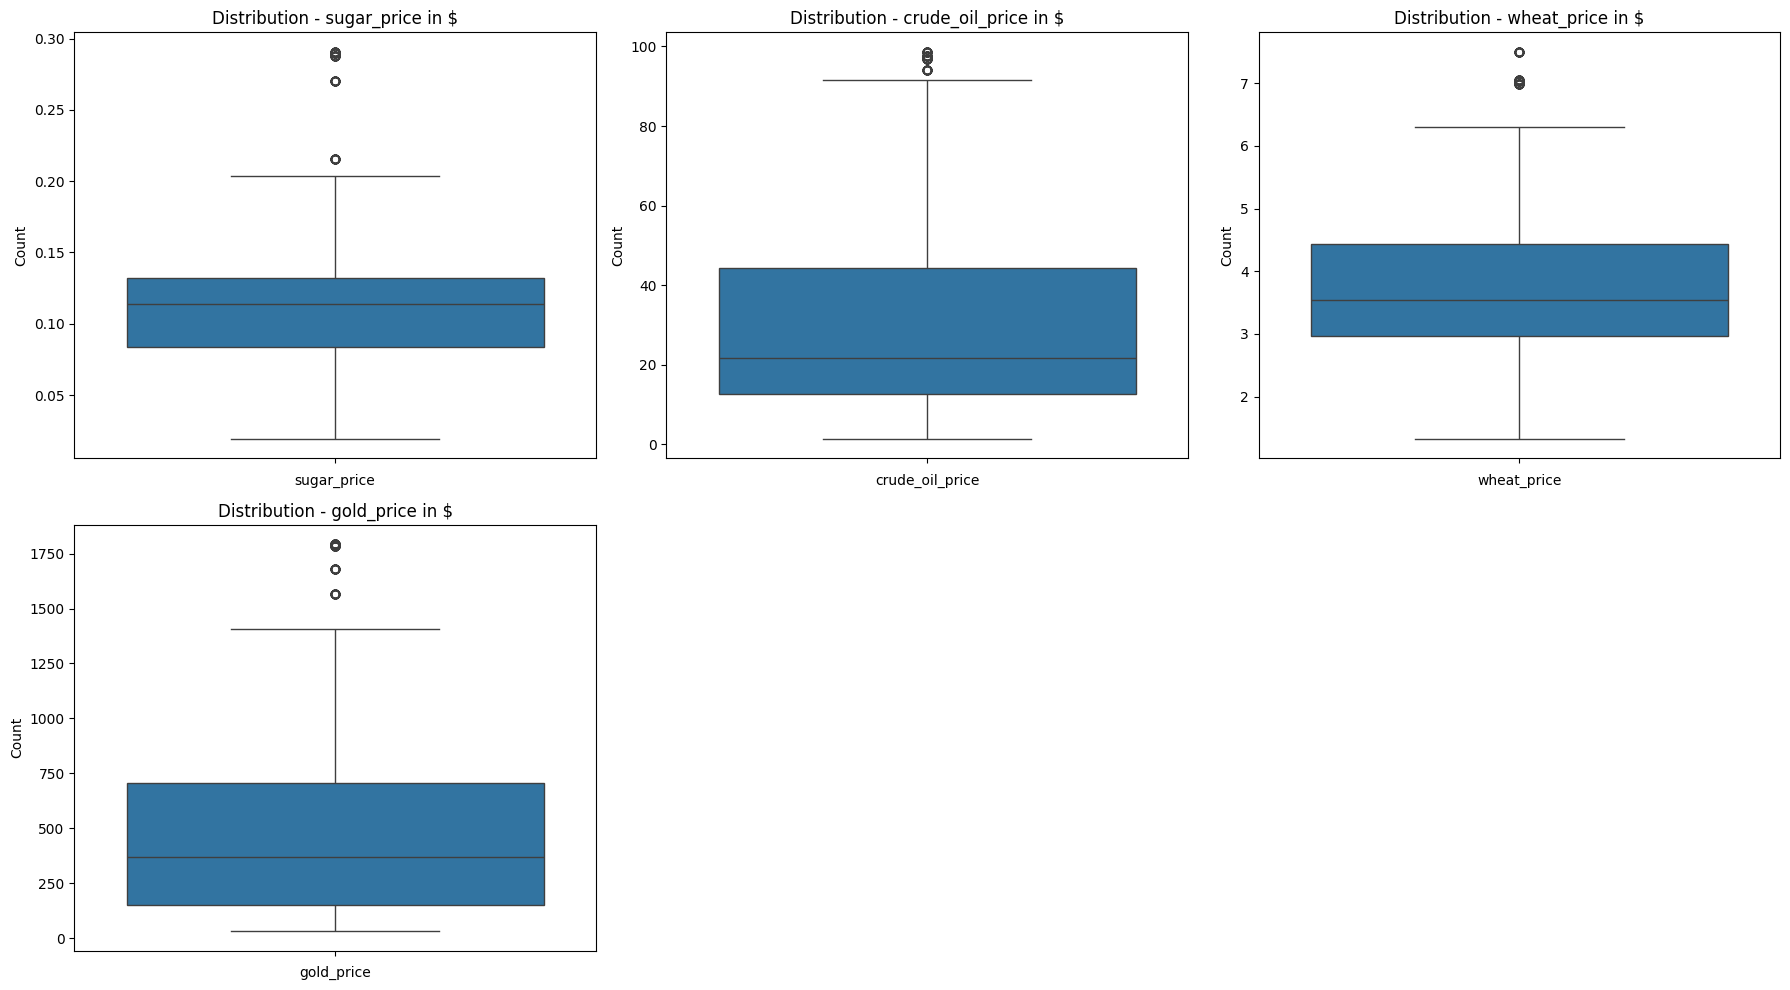

In [51]:
def plot_distribution(df, columns, figsize=(18, 10)):
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)  

    axes = axes.flatten()
    
    for i, col in enumerate(columns):  # enumerate 
        if df[col].dtype in ['float64', 'int64']: 
            sns.boxplot(df[col], ax=axes[i])
            axes[i].set_title(f"Distribution - {col} in $")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Count")
        else:
            axes[i].set_title(f"{col} - Not numeric")
            axes[i].set_visible(False)
    
    for j in range(len(columns), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


plot_distribution(clean_data, [
    'sugar_price',
    'crude_oil_price',
    'wheat_price',
    'gold_price'
    
])

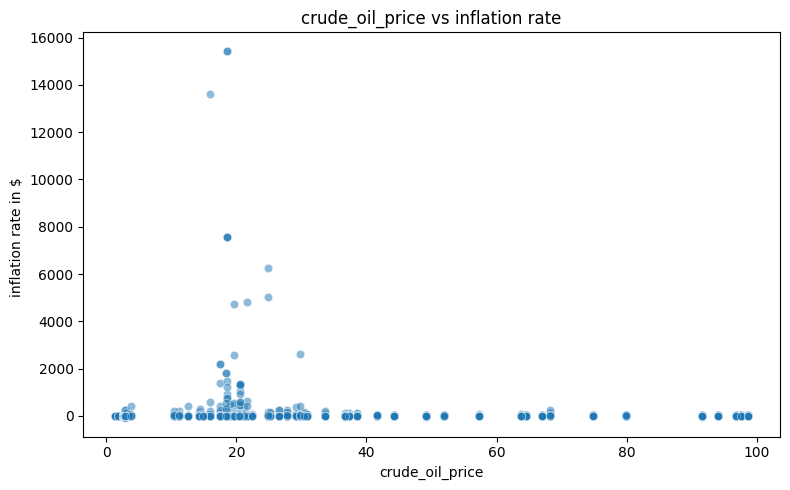

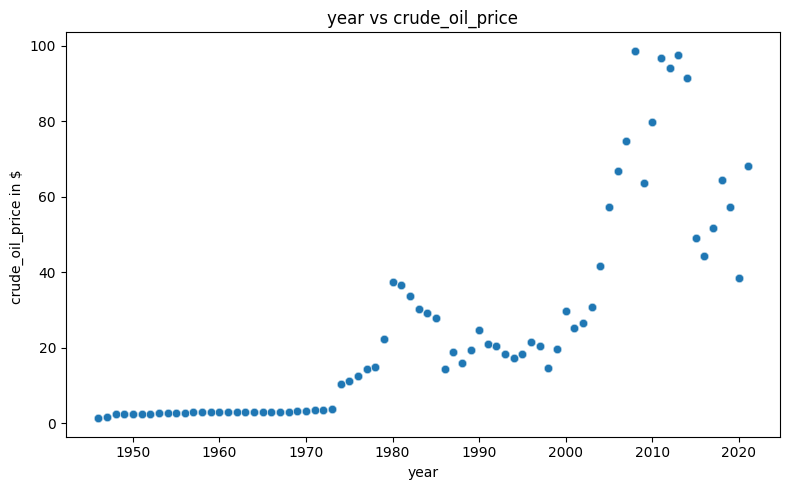

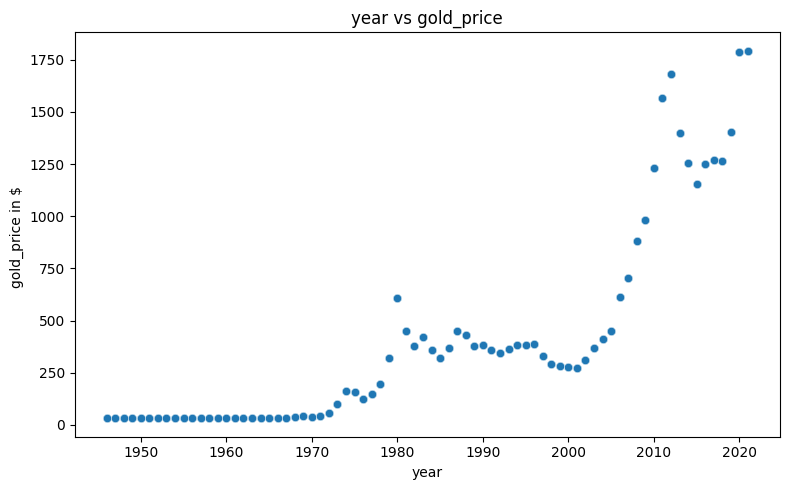

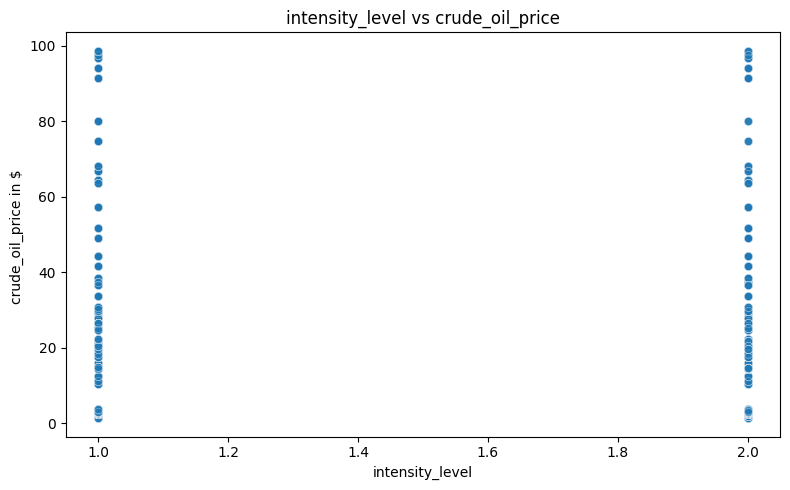

In [52]:
def plot_scatter(df, x_col, y_col, figsize=(8, 5)):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.scatterplot(data=df, x=x_col, y=y_col, ax=ax, alpha=0.5)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(f'{y_col} in $ ')
    
    plt.tight_layout()
    plt.show()

# Meaningful comparisons
plot_scatter(clean_data, 'crude_oil_price', 'inflation rate')
plot_scatter(clean_data, 'year', 'crude_oil_price')
plot_scatter(clean_data, 'year', 'gold_price')
plot_scatter(clean_data, 'intensity_level', 'crude_oil_price')

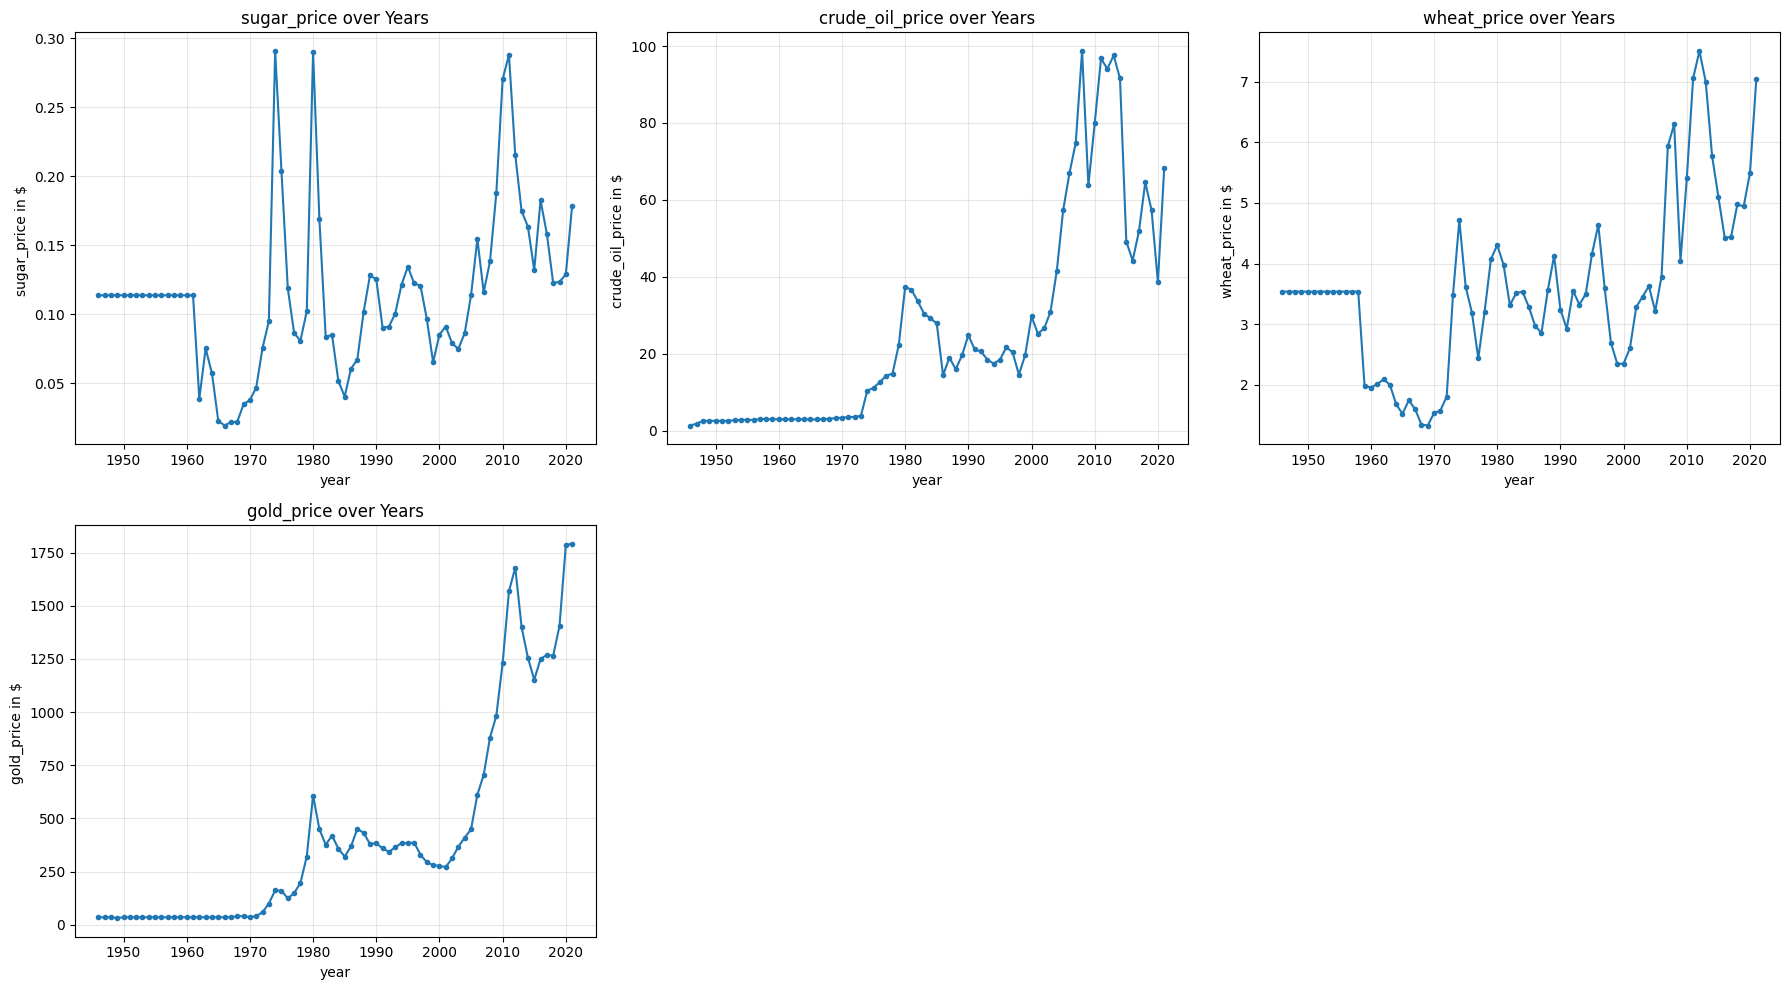

In [53]:
def plot_line(df, x_col, y_columns, figsize=(18, 10)):
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(y_columns):
        
        yearly = df.groupby(x_col)[col].mean().reset_index()
        
        axes[i].plot(yearly[x_col], yearly[col], marker='o', markersize=3)
        axes[i].set_title(f"{col} over Years")
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel(f'{col} in $ ')
        axes[i].grid(True, alpha=0.3)
    
    for j in range(len(y_columns), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


plot_line(clean_data, 'year', [
    'sugar_price',
    'crude_oil_price',
    'wheat_price',
    'gold_price',
])


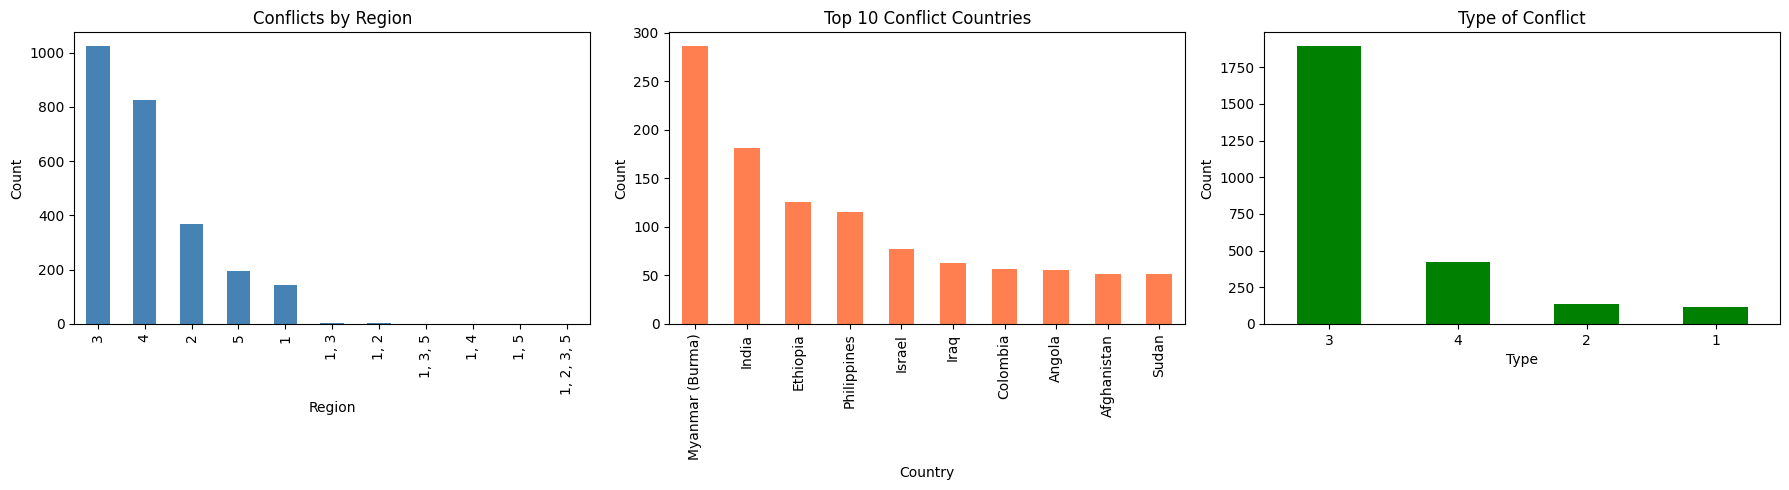

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Region wise conflicts
clean_data['region'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title("Conflicts by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=90)

# 2. Top 10 countries
clean_data['location'].value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title("Top 10 Conflict Countries")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=90)

# 3. Conflict type
clean_data['type_of_conflict'].value_counts().plot(
    kind='bar', ax=axes[2], color='green'
)
axes[2].set_title("Type of Conflict")
axes[2].set_xlabel("Type")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## region number and region name

* 1 = Europe
* 2 = Middle East
* 3 = Asia
* 4 = Africa
* 5 = Americas

## Type of wars 
* Type 1 → Extra-systemic  (colonial wars)
* Type 2 → Interstate      (country vs country) ← traditional war
* Type 3 → Intrastate      (civil war, insurgency) ← India wale mostly yahi
* Type 4 → Internationalized (bahar se support wali civil war)

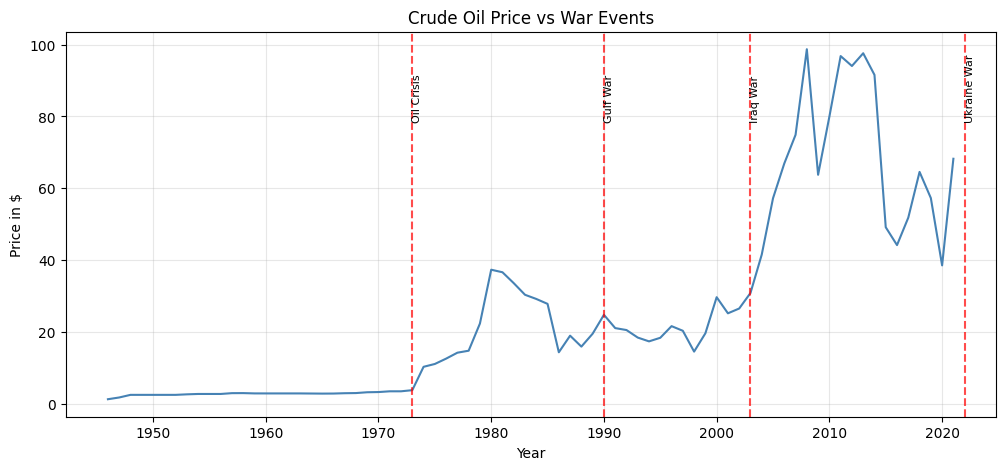

In [55]:

plt.figure(figsize=(12, 5))
yearly = clean_data.groupby('year')['crude_oil_price'].mean()
plt.plot(yearly.index, yearly.values, color='steelblue')

# Famous war years mark karo
war_years = {1973: 'Oil Crisis', 1990: 'Gulf War', 
             2003: 'Iraq War', 2022: 'Ukraine War'}

for year, label in war_years.items():
    plt.axvline(x=year, color='red', linestyle='--', alpha=0.7)
    plt.text(year, yearly.max()*0.8, label, rotation=90, fontsize=8)

plt.title("Crude Oil Price vs War Events")
plt.xlabel("Year")
plt.ylabel("Price in $")
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'war_events' is not defined

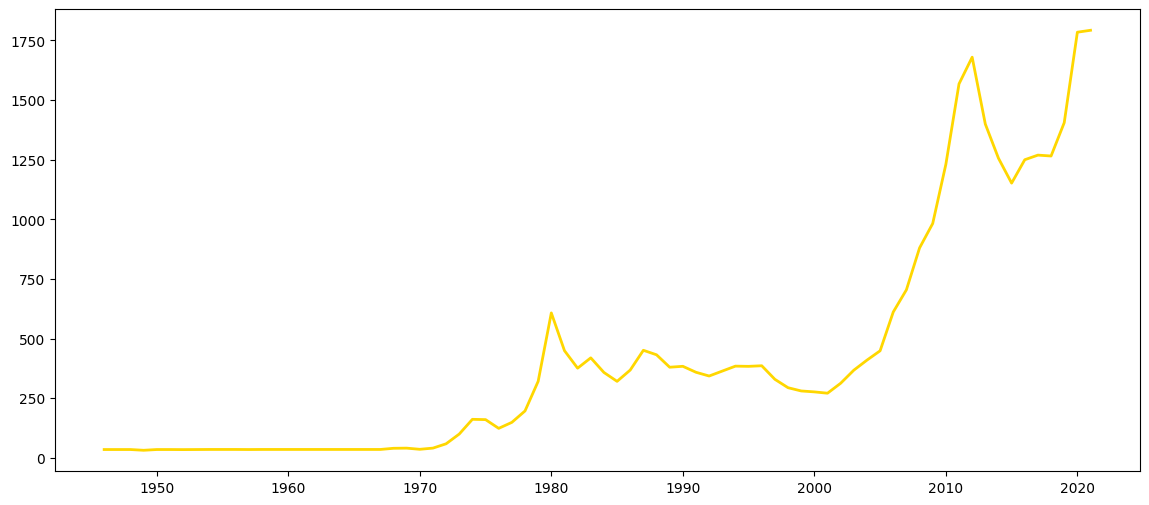

In [56]:
plt.figure(figsize=(14, 6))
yearly_gold = clean_data.groupby('year')['gold_price'].mean()
plt.plot(yearly_gold.index, yearly_gold.values,
         color='gold', linewidth=2)

for year, label in war_events.items():
    plt.axvline(x=year, color='red',
                linestyle='--', alpha=0.6, linewidth=1.5)
    plt.text(year+0.3, yearly_gold.max()*0.75,
             label, rotation=90, fontsize=8, color='red')

plt.fill_between(yearly_gold.index, yearly_gold.values,
                 alpha=0.1, color='gold')
plt.title("Gold Price vs Major War Events", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))
yearly_conflicts = clean_data.groupby('year')['conflict_id'].count()
plt.bar(yearly_conflicts.index, yearly_conflicts.values,
        color='coral', alpha=0.7)
plt.title("Total Conflicts per Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Conflicts")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()